In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score

In [12]:
df = pd.read_csv('/content/Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [13]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


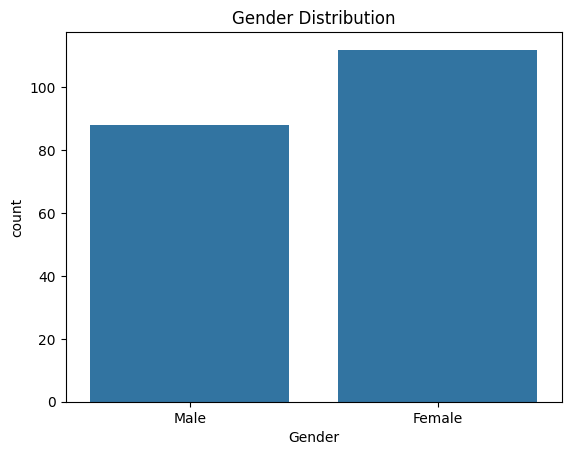

In [14]:
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.show()

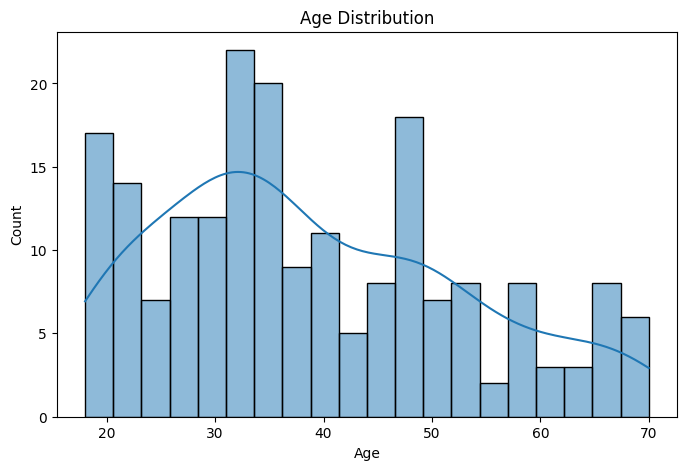

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'],
             bins=20,
             kde=True)

plt.title('Age Distribution')

plt.show()

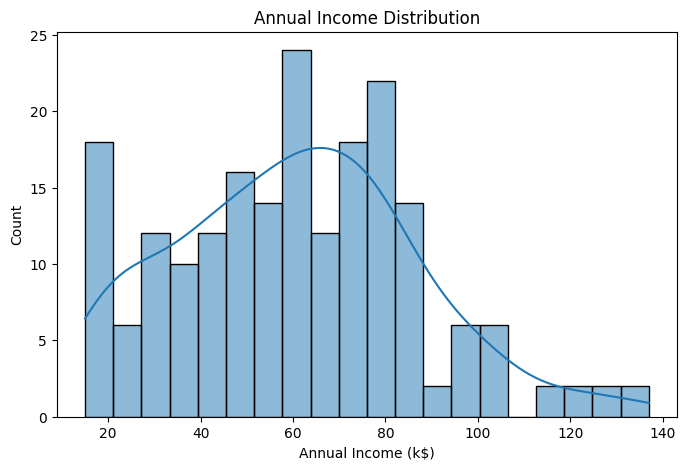

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df['Annual Income (k$)'],
             bins=20,
             kde=True)

plt.title('Annual Income Distribution')

plt.show()

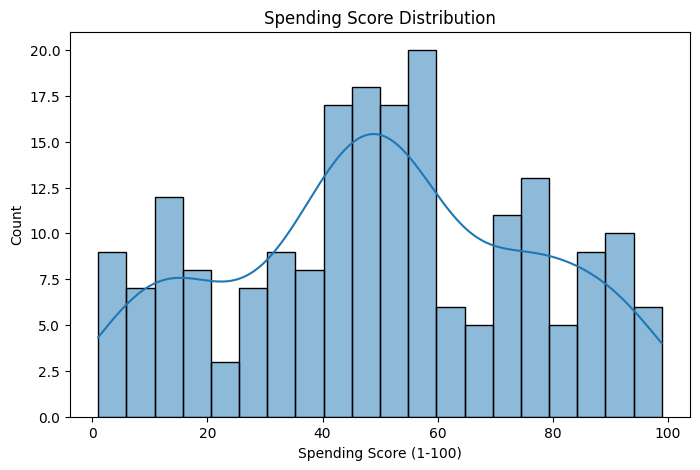

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df['Spending Score (1-100)'],
             bins=20,
             kde=True)

plt.title('Spending Score Distribution')

plt.show()

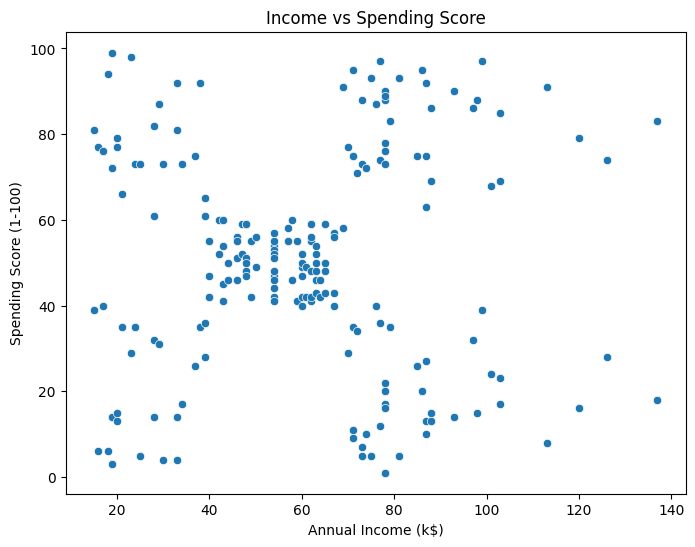

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)

plt.title('Income vs Spending Score')

plt.show()

In [19]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

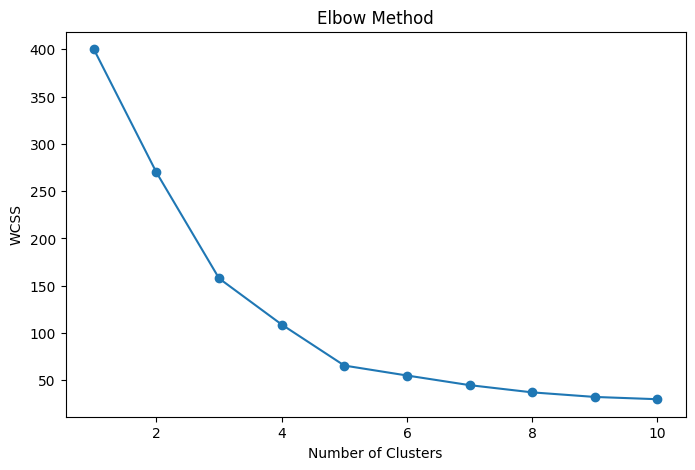

In [20]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11),
         wcss,
         marker='o')

plt.xlabel('Number of Clusters')

plt.ylabel('WCSS')

plt.title('Elbow Method')

plt.show()

In [21]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

In [22]:
score = silhouette_score(
    X_scaled,
    clusters
)

print("Silhouette Score:", score)

Silhouette Score: 0.5546571631111091


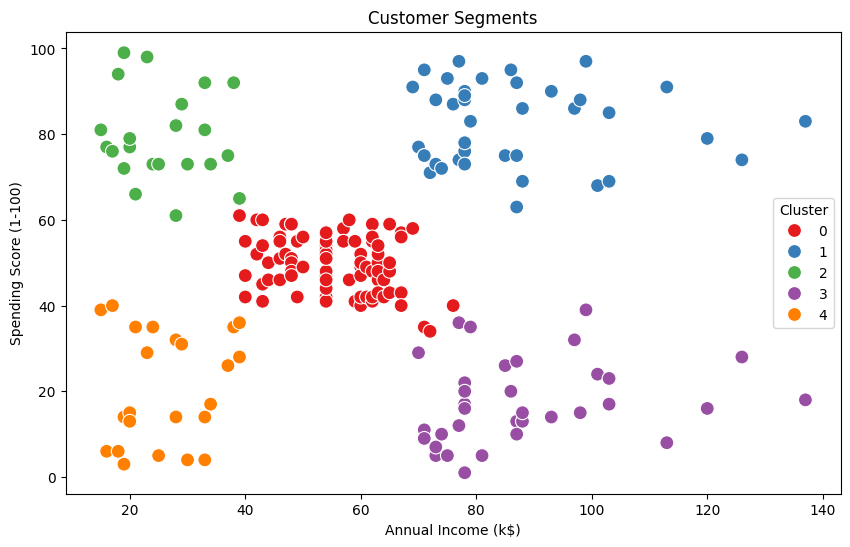

In [23]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    data=df,
    s=100
)

plt.title('Customer Segments')

plt.show()

In [24]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]

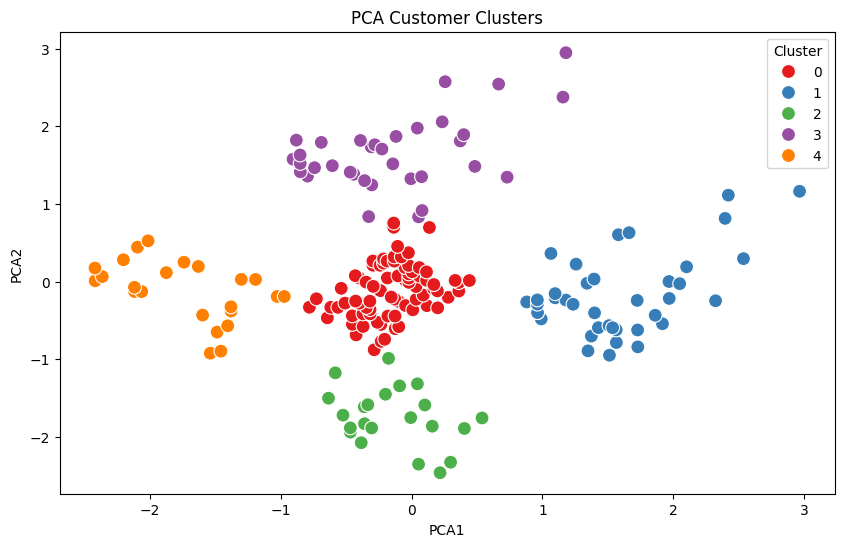

In [25]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='Set1',
    data=df,
    s=100
)

plt.title('PCA Customer Clusters')

plt.show()

In [26]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)

print(cluster_summary)

         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)  \
Cluster                                                                      
0         86.320988  42.716049           55.296296               49.518519   
1        162.000000  32.692308           86.538462               82.128205   
2         23.090909  25.272727           25.727273               79.363636   
3        164.371429  41.114286           88.200000               17.114286   
4         23.000000  45.217391           26.304348               20.913043   

             PCA1      PCA2  
Cluster                      
0       -0.160774 -0.123359  
1        1.577616 -0.175306  
2       -0.139560 -1.740701  
3       -0.162236  1.654235  
4       -1.728511 -0.120599  
